# CatBoost — 预订概率预测

In [20]:
import pandas as pd
import numpy as np
import os, joblib
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, RocCurveDisplay
)
import warnings; warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data', 'processed_data.csv')
MODEL_DIR  = os.path.join(BASE_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

print('数据路径:', DATA_PATH)

数据路径: d:\School\msba\作业\5113\group\sg\data\processed_data.csv


## 1. 读取数据 & 划分

In [21]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'数据形状: {df.shape}  预订率: {df["booked"].mean():.2%}')

FEATURES = [c for c in df.columns if c not in ['booked', 'listing_id']]
X = df[FEATURES]
y = df['booked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CatBoost 原生支持 NaN，无需额外处理
# 标记经过 label encoding 的整数列为分类特征，让 CatBoost 更好处理
CAT_FEATURES = ['host_response_time', 'neighbourhood_cleansed',
                'neighbourhood_group_cleansed', 'property_type', 'room_type']
cat_idx = [FEATURES.index(c) for c in CAT_FEATURES if c in FEATURES]

train_pool = Pool(X_train, y_train, cat_features=cat_idx)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx)
print(f'训练集: {X_train.shape}  测试集: {X_test.shape}')

数据形状: (1336630, 20)  预订率: 32.10%
训练集: (1069304, 18)  测试集: (267326, 18)


## 2. 训练 CatBoost

In [22]:
model = CatBoostClassifier(
    iterations            = 500,
    learning_rate         = 0.05,
    depth                 = 6,
    l2_leaf_reg           = 3,
    auto_class_weights    = 'Balanced',   # 处理类别不平衡
    eval_metric           = 'AUC',
    early_stopping_rounds = 50,
    task_type             = 'GPU',        # GPU 加速
    random_seed           = 42,
    verbose               = 100,
)

model.fit(train_pool, eval_set=test_pool)
print(f'最优迭代轮数: {model.best_iteration_}')

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8371379	best: 0.8371379 (0)	total: 52.5ms	remaining: 26.2s
100:	test: 0.9168312	best: 0.9168312 (100)	total: 3.74s	remaining: 14.8s
200:	test: 0.9360463	best: 0.9360463 (200)	total: 7.42s	remaining: 11s
300:	test: 0.9476578	best: 0.9476578 (300)	total: 11.1s	remaining: 7.32s
400:	test: 0.9551829	best: 0.9551829 (400)	total: 14.7s	remaining: 3.63s
499:	test: 0.9612544	best: 0.9612544 (499)	total: 18.2s	remaining: 0us
bestTest = 0.9612543583
bestIteration = 499
最优迭代轮数: 499


## 3. 评估

In [23]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)
print(f'AUC-ROC : {auc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['not booked','booked']))

AUC-ROC : 0.9613
F1 Score: 0.8474

Classification Report:
              precision    recall  f1-score   support

  not booked       0.94      0.91      0.92    181507
      booked       0.83      0.87      0.85     85819

    accuracy                           0.90    267326
   macro avg       0.88      0.89      0.89    267326
weighted avg       0.90      0.90      0.90    267326



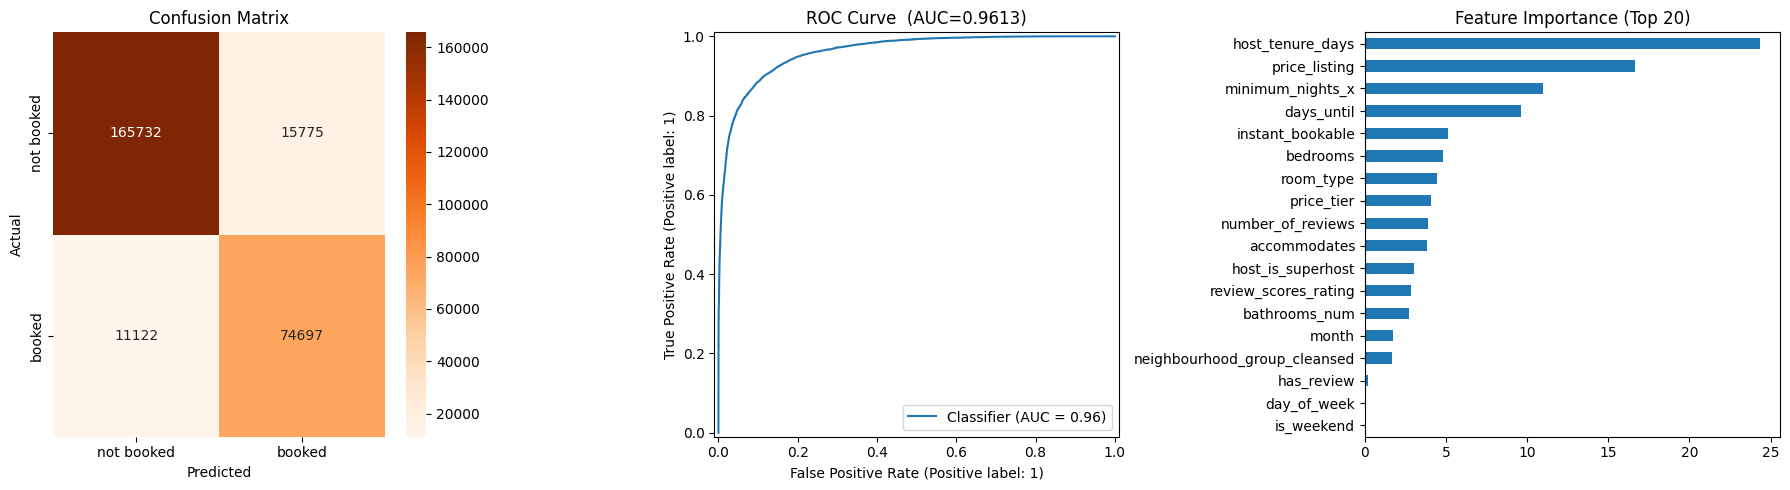

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['not booked','booked'],
            yticklabels=['not booked','booked'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC 曲线
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve  (AUC={auc:.4f})')

# 特征重要性 Top20
imp = pd.Series(
    model.get_feature_importance(), index=FEATURES
).nlargest(20)
imp.sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Feature Importance (Top 20)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'catboost_eval.png'), dpi=120)
plt.show()

## 5. 示例预测

In [25]:
# 从测试集随机取 5 条，展示模型输出的预订概率
sample = X_test.sample(5, random_state=0).copy()
sample['actual_booked']    = y_test.loc[sample.index].values
sample['pred_probability'] = model.predict_proba(sample[FEATURES])[:, 1].round(4)

show_cols = ['days_until', 'day_of_week', 'is_weekend', 'month',
             'room_type', 'neighbourhood_group_cleansed',
             'price_listing', 'review_scores_rating',
             'actual_booked', 'pred_probability']
show_cols = [c for c in show_cols if c in sample.columns]
print('=== 预订概率示例（从测试集随机抽取）===')
sample[show_cols].reset_index(drop=True)

=== 预订概率示例（从测试集随机抽取）===


,days_until,day_of_week,is_weekend,month,room_type,neighbourhood_group_cleansed,price_listing,review_scores_rating,actual_booked,pred_probability
0,73,2,0,12,0,1,NaN,NaN,1,0.9787
1,46,3,0,11,0,0,NaN,NaN,1,0.9901
2,294,6,1,7,2,0,194.0,NaN,0,0.1150
3,87,2,0,12,2,4,NaN,5.0,1,0.8324
4,20,5,1,10,2,0,232.0,NaN,0,0.0739


## 4. 保存模型

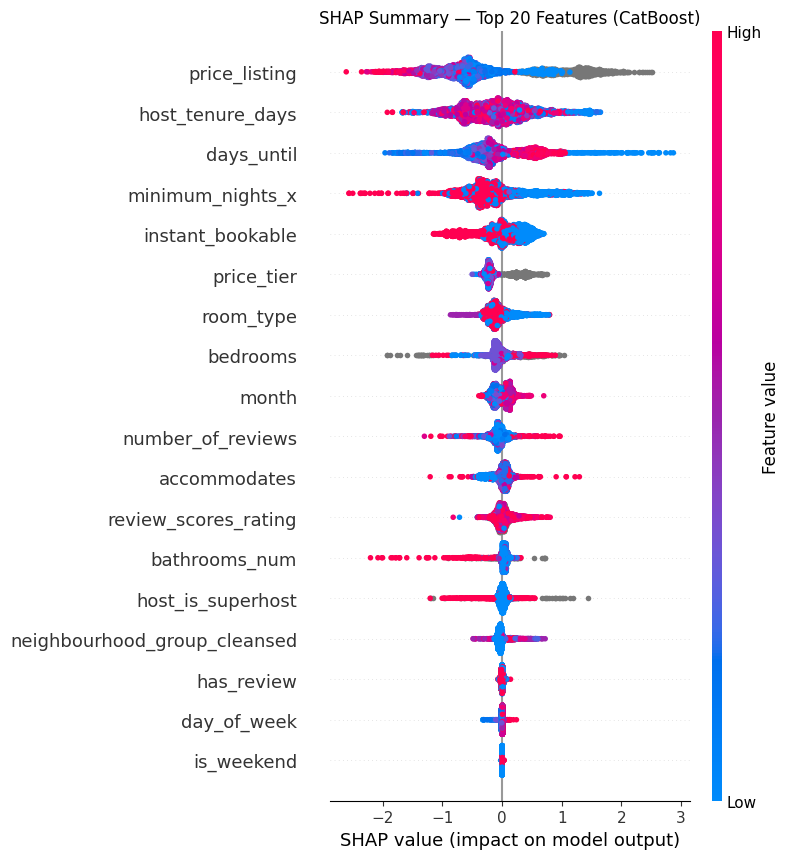

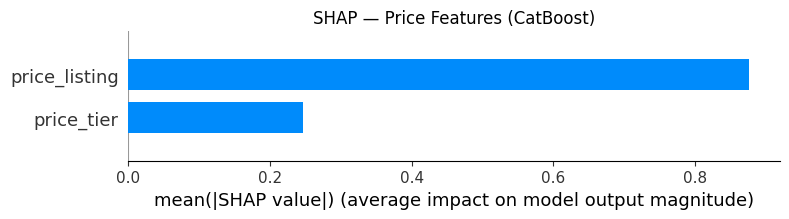

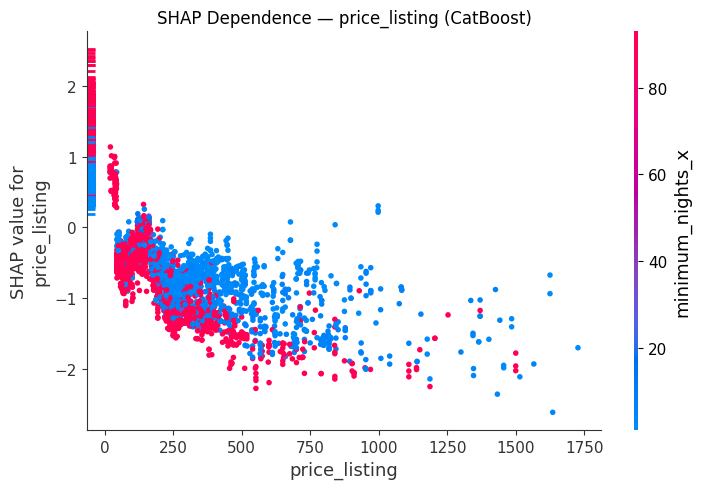

In [26]:
# ── Price 相关特征的全局 SHAP 分析 ────────────────────────────
import shap

sample_idx = X_test.sample(5000, random_state=42).index
X_shap = X_test.loc[sample_idx][FEATURES]

# CatBoost 用 shap 内置接口
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# ── 1. 全局 Beeswarm ─────────────────────────────────────────
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (CatBoost)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'catboost_shap_summary.png'), dpi=120)
plt.show()

# ── 2. Price 相关列 bar chart ─────────────────────────────────
price_cols = [c for c in FEATURES if 'price' in c or 'revenue' in c]
price_idx  = [FEATURES.index(c) for c in price_cols]

shap.summary_plot(sv[:, price_idx], X_shap[price_cols],
                  plot_type='bar', show=False)
plt.title('SHAP — Price Features (CatBoost)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'catboost_shap_price_bar.png'), dpi=120)
plt.show()

# ── 3. price_listing dependence plot ─────────────────────────
if 'price_listing' in FEATURES:
    shap.dependence_plot('price_listing', sv, X_shap, show=False)
    plt.title('SHAP Dependence — price_listing (CatBoost)')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'catboost_shap_price_dep.png'), dpi=120)
    plt.show()

In [27]:
# 保存模型（joblib pkl，含 feature list 和分类特征索引）
model_path = os.path.join(MODEL_DIR, 'catboost_model.pkl')
joblib.dump({'model': model, 'features': FEATURES, 'cat_idx': cat_idx}, model_path)
print(f'模型已保存: {model_path}')

模型已保存: d:\School\msba\作业\5113\group\sg\model\catboost_model.pkl


In [28]:
# ── 推理示例：load pkl → 输出预订概率 ────────────────────────
saved = joblib.load(os.path.join(MODEL_DIR, 'catboost_model.pkl'))
loaded_model    = saved['model']
loaded_features = saved['features']

# 取测试集中 3 条作为"新数据"模拟推理
new_data = X_test.iloc[:3][loaded_features].copy()
probs = loaded_model.predict_proba(new_data)[:, 1]

result = new_data[['days_until', 'is_weekend', 'room_type',
                   'price_listing']].copy()
result['pred_prob_booked'] = probs.round(4)
print('=== 推理示例（load pkl）===')
result.reset_index(drop=True)

=== 推理示例（load pkl）===


,days_until,is_weekend,room_type,price_listing,pred_prob_booked
0,59,0,1,392.0,0.5690
1,191,0,0,381.0,0.0592
2,273,1,2,NaN,0.9739
